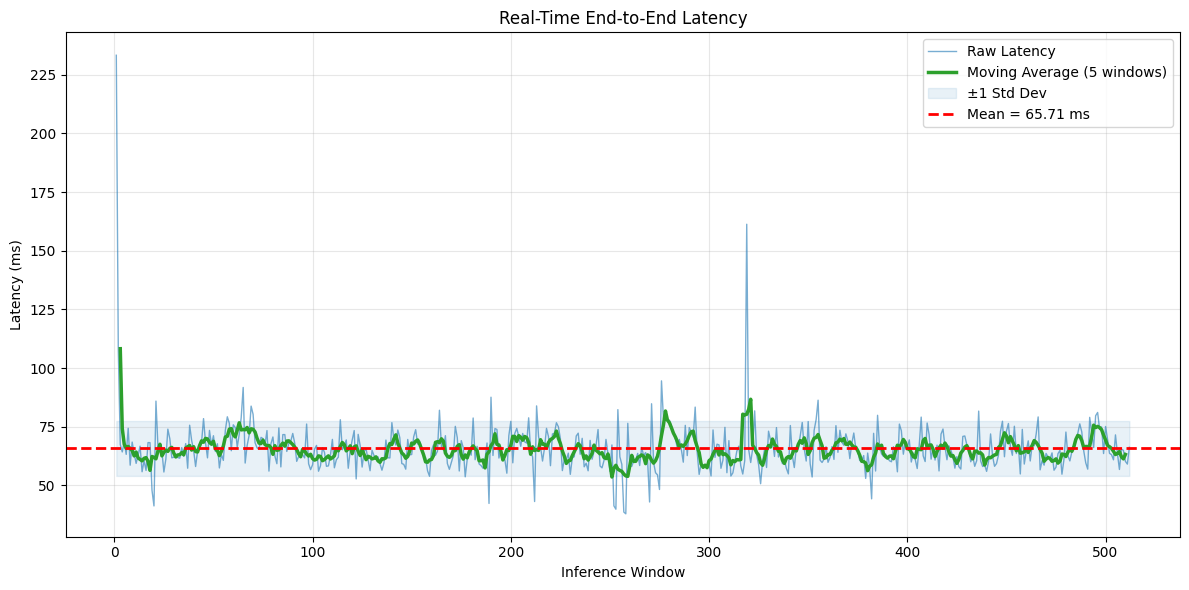

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Load log
with open("../real-time.log", "r") as f:
    log = f.read()

# Extract latency (matching both old and new log formats)
latencies = [
    float(x)
    for x in re.findall(
        r"(?:End-to-end latency from trigger = |Total latency \(from trigger frame arrival\): )([0-9.]+) ms",
        log
    )
]

if latencies:
    df = pd.DataFrame({
        "window": range(1, len(latencies)+1),
        "latency": latencies
    })

    # Smooth dengan moving average
    df["smooth"] = (
        df["latency"]
        .rolling(window=5, center=True)
        .mean()
    )

    mean_latency = df["latency"].mean()
    std_latency = df["latency"].std()

    plt.figure(figsize=(12, 6))

    # Data asli dibuat transparan
    plt.plot(
        df["window"],
        df["latency"],
        linewidth=1,
        label="Raw Latency",
        color="#1f77b4",
        alpha=0.6
    )

    # Trend yang lebih smooth
    plt.plot(
        df["window"],
        df["smooth"],
        linewidth=2.5,
        label="Moving Average (5 windows)",
        color="#2ca02c"
    )

    # Area stabilitas
    plt.fill_between(
        df["window"],
        mean_latency - std_latency,
        mean_latency + std_latency,
        color="#1f77b4",
        alpha=0.1,
        label="±1 Std Dev"
    )

    plt.axhline(
        mean_latency,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_latency:.2f} ms"
    )

    plt.title("Real-Time End-to-End Latency")
    plt.xlabel("Inference Window")
    plt.ylabel("Latency (ms)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No end-to-end latency data found in log.")


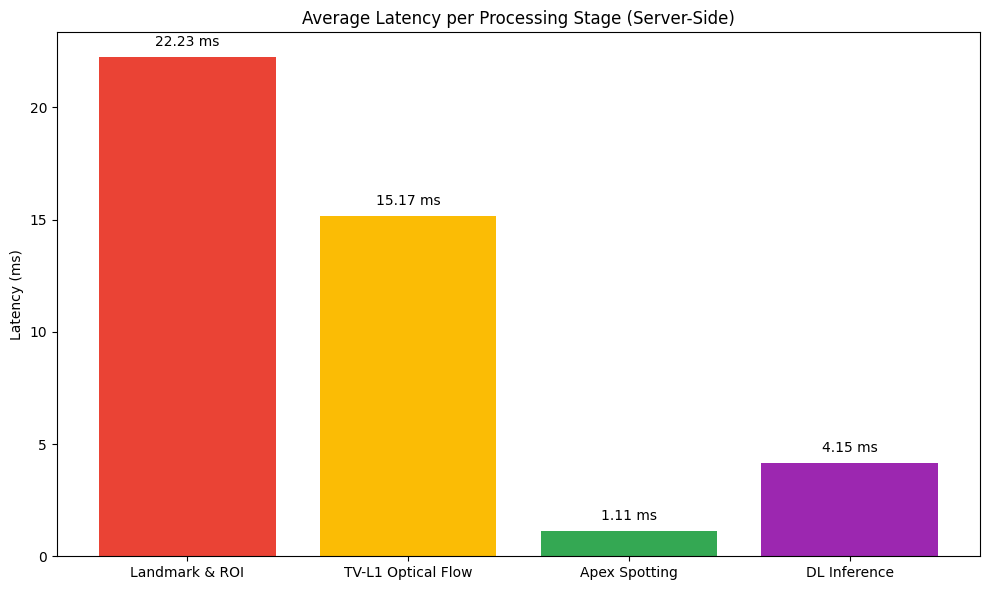

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt

with open("../real-time.log", "r") as f:
    log = f.read()

# 1. Video frame acquisition & transmission (WebRTC)
webrtc = [
    float(x)
    for x in re.findall(
        r"Video frame acquisition & transmission \(WebRTC\): avg = ([0-9.]+) ms",
        log,
    )
]
if not webrtc:
    webrtc = [
        float(x)
        for x in re.findall(
            r"WebRTC latency = ([0-9.]+) ms",
            log,
        )
    ]

# 2. Face detection & landmark extraction (Landmark & ROI)
roi = [
    float(x)
    for x in re.findall(
        r"Face detection & landmark extraction: avg = ([0-9.]+) ms",
        log,
    )
]
if not roi:
    roi = [
        float(x)
        for x in re.findall(
            r"(?:Landmark & ROI latency|Landmark detection & ROI cropping completed\. Latency|ROI cropping completed\. Latency) =?:?\s*([0-9.]+) ms",
            log,
        )
    ]

# 3. TVL1 optical flow computation (Optical Flow)
flow = [
    float(x)
    for x in re.findall(
        r"TVL1 optical flow computation: avg = ([0-9.]+) ms",
        log,
    )
]
if not flow:
    flow = [
        float(x)
        for x in re.findall(
            r"(?:Optical flow \(TV-L1\) calculation completed\. Latency|TV-L1\) calculation completed\. Latency) completed\. Latency: ([0-9.]+) ms",
            log,
        )
    ]
if not flow:
    # Fallback to direct pattern if needed
    flow = [
        float(x)
        for x in re.findall(
            r"calculation completed\. Latency: ([0-9.]+) ms",
            log,
        )
    ]

# 4. Apex phase spotting (Apex Spotting)
spotting = [
    float(x)
    for x in re.findall(
        r"Apex phase spotting: ([0-9.]+) ms",
        log,
    )
]

# 5. Deep learning model inference (DL Inference)
infer = [
    float(x)
    for x in re.findall(
        r"Deep learning model inference: ([0-9.]+) ms",
        log,
    )
]
if not infer:
    infer = [
        float(x)
        for x in re.findall(
            r"Execution time = ([0-9.]+) ms",
            log,
        )
    ]

labels = [
    "Landmark & ROI",
    "TV-L1 Optical Flow",
    "Apex Spotting",
    "DL Inference"
]

means = [
    np.mean(roi) if roi else 0.0,
    np.mean(flow) if flow else 0.0,
    np.mean(spotting) if spotting else 0.0,
    np.mean(infer) if infer else 0.0
]

plt.figure(figsize=(10,6))
bars = plt.bar(labels, means, color=['#EA4335', '#FBBC05', '#34A853', '#9C27B0'])

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.5,
        f"{bar.get_height():.2f} ms",
        ha="center"
    )

plt.title("Average Latency per Processing Stage (Server-Side)")
plt.ylabel("Latency (ms)")
plt.tight_layout()
plt.show()


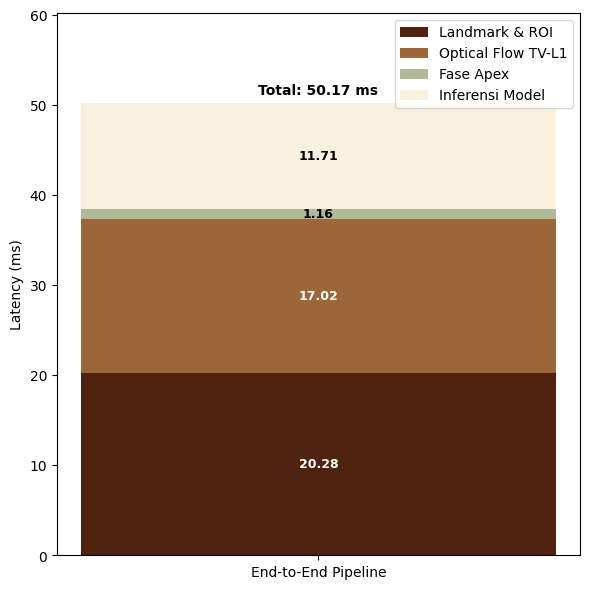

In [2]:
import matplotlib.pyplot as plt

# Data latensi (ms)
stages = [
    "Landmark & ROI",
    "Optical Flow TV-L1",
    "Fase Apex",
    "Inferensi Model"
]

latency = [20.28, 17.02, 1.16, 11.71]

# Total latency
total_latency = sum(latency)

# Membuat stacked bar
fig, ax = plt.subplots(figsize=(6, 6))

bottom = 0
colors = ["#4E220F", "#9D6638", "#B0BA99", "#F7F1DE"]

for i in range(len(stages)):
    ax.bar(
        "End-to-End Pipeline",
        latency[i],
        bottom=bottom,
        label=stages[i],
        color=colors[i]
    )

    # Tambahkan nilai pada tiap segmen
    ax.text(
        0,                              # posisi x
        bottom + latency[i] / 2,        # tengah segmen
        f"{latency[i]:.2f}",
        ha="center",
        va="center",
        fontsize=9,
        color="white" if i < 2 else "black",
        fontweight="bold"
    )

    bottom += latency[i]

# Tambahkan total annotation
ax.text(
    0,
    total_latency + 1,
    f"Total: {total_latency:.2f} ms",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

# Styling
ax.set_ylabel("Latency (ms)")
ax.legend(loc="upper right")
ax.set_ylim(0, total_latency + 10)

plt.tight_layout()
plt.show()